# Do Bulk & Block Deals Predict Stock Price Movements?
## An Event Study on NSE

**Data Source:** NSE Bulk Deals + yfinance  
**Methodology:** Event Study Analysis

---
## Data Collection & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
import os

warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries imported.')

Libraries imported.


In [2]:
df = pd.read_csv('Bulk-Deals-24-04-2025-to-24-04-2026.csv')
print(f'Loaded {len(df)} rows')
df.head()

Loaded 21901 rows


,Date,Symbol,Security Name,Client Name,Buy / Sell,Quantity Traded,Trade Price / Wght. Avg. Price,Remarks
0,24-APR-2025,AGSTRA,AGS Transact Tech Ltd,BAJAJ FINANCE LIMITED,SELL,"1,20,58,807",5.52,-
1,24-APR-2025,AGSTRA,AGS Transact Tech Ltd,DEVI TRADERS LLP,SELL,"2,50,000",6.11,-
2,24-APR-2025,AGSTRA,AGS Transact Tech Ltd,DEVI TRADERS LLP,BUY,"30,00,000",5.52,-
3,24-APR-2025,AGSTRA,AGS Transact Tech Ltd,ISHAAN TRADEFIN LLP,BUY,"38,00,000",5.53,-
4,24-APR-2025,AGSTRA,AGS Transact Tech Ltd,MULTIPLIER SHARE & STOCK ADVISORS PRIVATE LIMITED,BUY,"25,00,000",5.52,-


In [3]:
df.columns = ['Date', 'Symbol', 'Security_Name', 'Client_Name', 'Buy_Sell', 'Quantity', 'Trade_Price', 'Remarks']
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Buy_Sell'] = df['Buy_Sell'].str.strip().str.upper()

print(df.dtypes)

Date             datetime64[ns]
Symbol                   object
Security_Name            object
Client_Name              object
Buy_Sell                 object
Quantity                 object
Trade_Price              object
Remarks                  object
dtype: object


In [6]:
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique stocks: {df['Symbol'].nunique()}")
print(f"Unique clients: {df['Client_Name'].nunique()}")

print(f"BUY transactions: {(df['Buy_Sell'] == 'BUY').sum()} ({(df['Buy_Sell'] == 'BUY').mean() * 100:.1f}%)")
print(f"SELL transactions: {(df['Buy_Sell'] == 'SELL').sum()} ({(df['Buy_Sell'] == 'SELL').mean() * 100:.1f}%)")

# Remove commas and convert to numeric BEFORE multiplying
df['Quantity'] = pd.to_numeric(df['Quantity'].astype(str).str.replace(',', ''), errors='coerce')
df['Trade_Price'] = pd.to_numeric(df['Trade_Price'].astype(str).str.replace(',', ''), errors='coerce')

# Calculate Deal Value
df['Deal_Value'] = df['Quantity'] * df['Trade_Price']

print(f"Avg deal value (BUY) Rs. {df[df['Buy_Sell'] == 'BUY']['Deal_Value'].mean() / 1e7:.2f} Cr")
print(f"Avg deal value (SELL) Rs. {df[df['Buy_Sell'] == 'SELL']['Deal_Value'].mean() / 1e7:.2f} Cr")
print(f"Largest single deal Rs. {df['Deal_Value'].max() / 1e7:.2f} Cr")

Date range: 2025-04-24 00:00:00 to 2026-04-23 00:00:00
Unique stocks: 1605
Unique clients: 3286
BUY transactions: 11004 (50.2%)
SELL transactions: 10897 (49.8%)
Avg deal value (BUY) Rs. 29.60 Cr
Avg deal value (SELL) Rs. 43.76 Cr
Largest single deal Rs. 12879.97 Cr


In [7]:
unique_symbols = df['Symbol'].dropna().unique()
tickers = [s + '.NS' for s in unique_symbols]

print("Downloading price data...")
price_data = yf.download(
    tickers,
    start='2024-01-01',
    end='2026-04-24',
    auto_adjust=True,
    progress=True,
    threads=True
)['Close']

price_data.index = price_data.index.tz_localize(None)
print(f"Downloaded shape: {price_data.shape}")

$ENCOMPAS.NS: possibly delisted; no timezone found
[                       0%                       ]$ENVIRO.NS: possibly delisted; no timezone found
[                       1%                       ]  22 of 1605 completed$ANZEN.NS: possibly delisted; no timezone found
[                       1%                       ]  24 of 1605 completed$SNEHAA.NS: possibly delisted; no timezone found
[*                      3%                       ]  41 of 1605 completed$PATELEG-RE.NS: possibly delisted; no timezone found
[*                      3%                       ]  42 of 1605 completed$SHUBHSHREE.NS: possibly delisted; no timezone found
[*                      3%                       ]  43 of 1605 completed$INVICTA.NS: possibly delisted; no timezone found
[*                      3%                       ]  44 of 1605 completed$SHETHJI.NS: possibly delisted; no timezone found
[*                      3%                       ]  44 of 1605 completed$UPLPP1.NS: possibly delisted; no timezone 

Downloaded shape: (573, 1605)


In [ ]:
results = []

for _, row in df.iterrows():
    symbol = str(row['Symbol']).strip()
    ns_symbol = symbol + '.NS'
    deal_date = row['Date']
    
    if pd.isna(deal_date) or ns_symbol not in price_data.columns:
        continue
    
    try:
        col_data = price_data[ns_symbol].dropna()
        future = col_data[col_data.index >= deal_date]
        
        if len(future) < 2:
            continue
        
        p0 = float(future.iloc[0])
        if p0 == 0 or np.isnan(p0):
            continue
        
        def ret(days, _col=col_data, _p0=p0, _date=deal_date):
            try:
                target = _date + pd.Timedelta(days=days)
                f = _col[_col.index >= target].dropna()
                return round((float(f.iloc[0]) - _p0) / _p0 * 100, 4) if len(f) > 0 else np.nan
            except:
                return np.nan
        
        # how this func works: It looks for the first price on or after the target date (deal_date + days). If found, it calculates the return from p0 to that price. If not found, it returns NaN.
        
        results.append({
            'Date': deal_date,
            'Symbol': symbol,
            'Security_Name': row['Security_Name'],
            'Client_Name': row['Client_Name'],
            'Buy_Sell': row['Buy_Sell'],
            'Quantity': row['Quantity'],
            'Trade_Price': row['Trade_Price'],
            'Price_D0': p0,
            'Return_1D': ret(1),
            'Return_5D': ret(5),
            'Return_10D': ret(10),
            'Return_30D': ret(30),
        })
    except:
        continue

print(f"Results collected: {len(results)}")

if len(results) > 0:
    event_df = pd.DataFrame(results)
    event_df['Label'] = (event_df['Return_30D'] > 0).astype(int)
    event_df.to_csv('event_study.csv', index=False)
    print(f'Saved {len(event_df)} rows to event_study.csv')
    print(event_df[['Symbol','Date','Return_1D','Return_5D','Return_30D','Label']].head(10))
else:
    print("Empty results dataframe.")

Results collected: 18667
Saved 18667 rows to event_study.csv
   Symbol       Date  Return_1D  Return_5D  Return_30D  Label
0  AGSTRA 2025-04-24     4.2553    -6.0557    -14.8936      0
1  AGSTRA 2025-04-24     4.2553    -6.0557    -14.8936      0
2  AGSTRA 2025-04-24     4.2553    -6.0557    -14.8936      0
3  AGSTRA 2025-04-24     4.2553    -6.0557    -14.8936      0
4  AGSTRA 2025-04-24     4.2553    -6.0557    -14.8936      0
5  AGSTRA 2025-04-24     4.2553    -6.0557    -14.8936      0
6  GATECH 2025-04-24    -1.3158   -10.5263      6.5789      1
7  GATECH 2025-04-24    -1.3158   -10.5263      6.5789      1
8  GATECH 2025-04-24    -1.3158   -10.5263      6.5789      1
9  GATECH 2025-04-24    -1.3158   -10.5263      6.5789      1


---
## Data Cleaning & Preparation

In [9]:
# Load event study data
edf = pd.read_csv('event_study.csv', parse_dates=['Date'])

rows_before = len(edf)
print(f'Rows before cleaning: {rows_before}')
print(f'Missing values:\n{edf.isnull().sum()}')

Rows before cleaning: 18667
Missing values:
Date                0
Symbol              0
Security_Name       0
Client_Name         0
Buy_Sell            0
Quantity            0
Trade_Price         0
Price_D0            0
Return_1D           0
Return_5D         214
Return_10D        426
Return_30D       1475
Label               0
dtype: int64


In [10]:
# Step-by-step cleaning

# 1. Drop rows with missing Symbol or Date
edf = edf.dropna(subset=['Symbol', 'Date'])

# 2. Remove duplicate rows
edf = edf.drop_duplicates()

# Fix data types first
edf['Quantity'] = pd.to_numeric(edf['Quantity'].astype(str).str.replace(',', ''), errors='coerce')
edf['Trade_Price'] = pd.to_numeric(edf['Trade_Price'].astype(str).str.replace(',', ''), errors='coerce')

# Now rerun cleaning
edf = edf.dropna(subset=['Symbol', 'Date'])
edf = edf.drop_duplicates()
edf = edf[edf['Quantity'] > 0]
edf = edf[edf['Trade_Price'] > 0]

# Remove outliers
for col in ['Return_1D', 'Return_5D', 'Return_10D', 'Return_30D']:
    mean, std = edf[col].mean(), edf[col].std()
    edf = edf[edf[col].between(mean - 5*std, mean + 5*std)]

# Add features
edf['DayOfWeek']     = edf['Date'].dt.dayofweek
edf['Month']         = edf['Date'].dt.month
edf['Year']          = edf['Date'].dt.year
edf['Is_Large_Deal'] = (edf['Quantity'] > edf['Quantity'].quantile(0.75)).astype(int)
edf['Deal_Value']    = edf['Quantity'] * edf['Trade_Price']

buy_df = edf[edf['Buy_Sell'] == 'BUY'].copy()

print(f'Rows before: {rows_before} | Rows after: {len(edf)}')
print(f'BUY events: {len(buy_df)}')
print(f'UP signals: {buy_df["Label"].sum()} | DOWN signals: {(buy_df["Label"]==0).sum()}')

Rows before: 18667 | Rows after: 17122
BUY events: 8423
UP signals: 3043 | DOWN signals: 5380


---
## Exploratory Data Analysis (EDA)

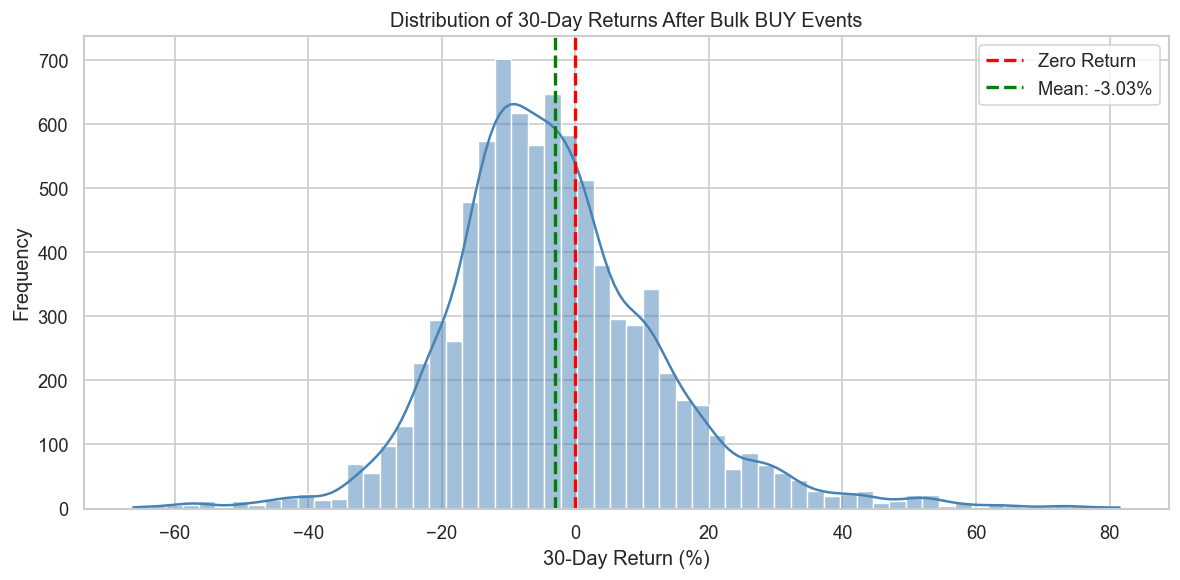

Mean 30D return: -3.03%
Positive return rate: 36.1%


In [11]:
# Plot 1: Distribution of 30-day returns after bulk BUY events
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(buy_df['Return_30D'].dropna(), bins=60, kde=True, color='steelblue', ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Return')
ax.axvline(buy_df['Return_30D'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {buy_df["Return_30D"].mean():.2f}%')

ax.set_title('Distribution of 30-Day Returns After Bulk BUY Events')
ax.set_xlabel('30-Day Return (%)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/01_return_distribution.png')
plt.show()

print(f"Mean 30D return: {buy_df['Return_30D'].mean():.2f}%")
print(f"Positive return rate: {(buy_df['Return_30D']>0).mean()*100:.1f}%")

### Inference 1: The "Smart Money" Myth
**Does following a bulk BUY guarantee a profit?** 

Contrary to common retail investor belief, the data suggests otherwise. The distribution of 30-day returns following a bulk BUY event is skewed negative, with an average return of **-3.03%**. Only about 36.1% of these events lead to positive returns. This indicates that a bulk deal alone is not a straightforward "buy" signal and often precedes a short-term correction.

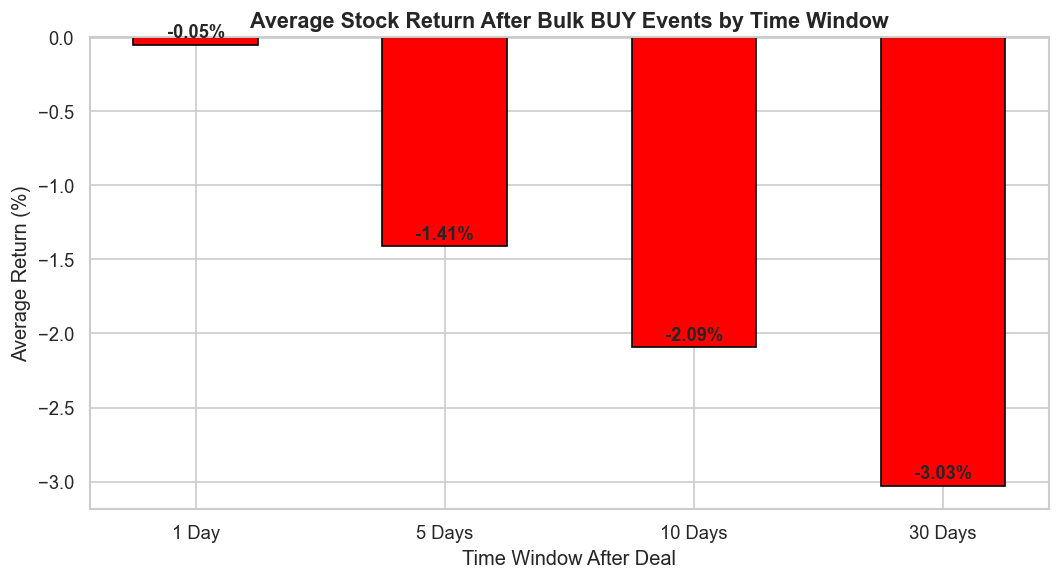

This chart shows whether the signal strengthens over time


In [12]:
# Plot 2: Average return by time window
windows = ['Return_1D', 'Return_5D', 'Return_10D', 'Return_30D']
labels = ['1 Day', '5 Days', '10 Days', '30 Days']
avg_returns = [buy_df[w].mean() for w in windows]
colors = ['green' if r > 0 else 'red' for r in avg_returns]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, avg_returns, color=colors, edgecolor='black', width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, avg_returns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Average Stock Return After Bulk BUY Events by Time Window', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Return (%)')
ax.set_xlabel('Time Window After Deal')
plt.tight_layout()
plt.savefig('outputs/02_avg_returns_by_window.png')
plt.show()
print('This chart shows whether the signal strengthens over time')

### Inference 2: Signal Decay Over Time
**How does the market react across different time horizons?**

The initial 1-day market reaction is relatively flat (-0.05%), indicating that the immediate price impact of the deal is minimal. However, the returns decay further as time progresses to 5, 10, and 30 days. This supports the Efficient Market Hypothesis: any informational edge the institution had is immediately priced in, and the subsequent drift is largely negative.

Top 3 buyers:
Client_Name
HRTI PRIVATE LIMITED                 793
GRAVITON RESEARCH CAPITAL LLP        678
JUNOMONETA FINSOL PRIVATE LIMITED    554
Name: count, dtype: int64


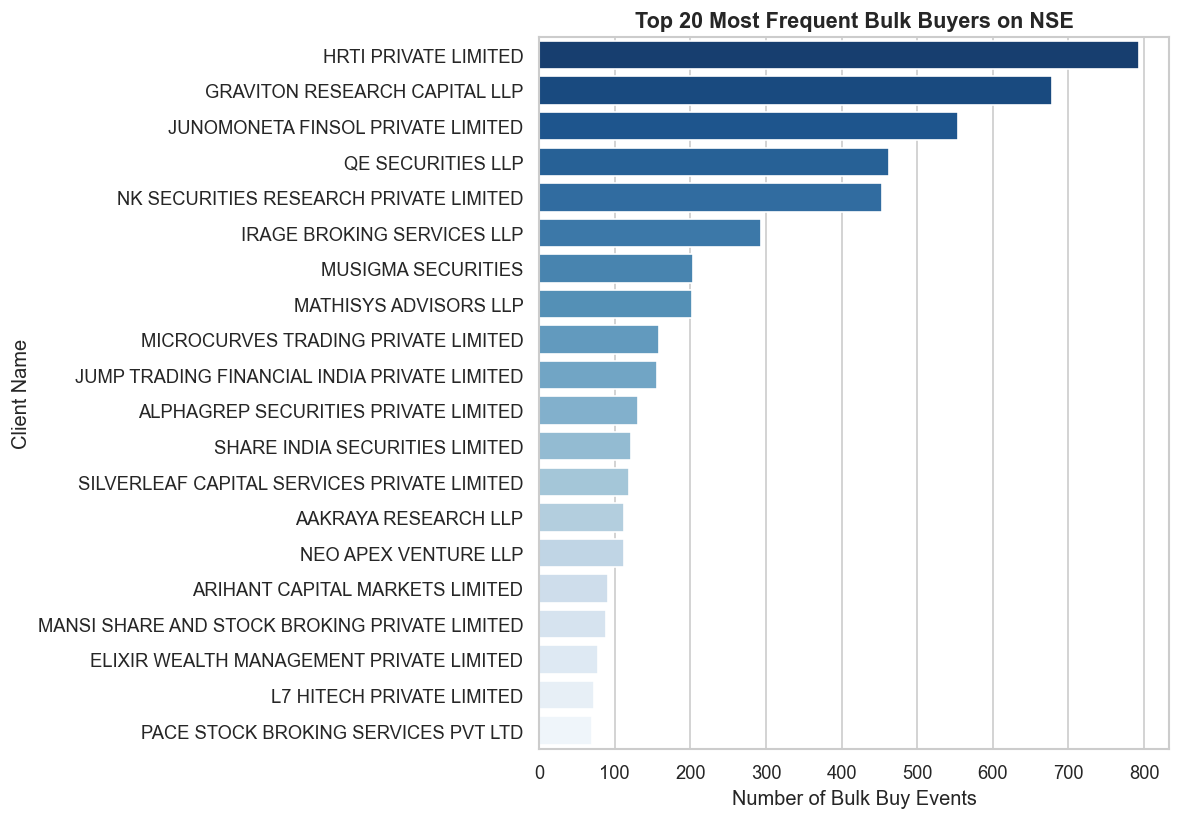

Top buyer: HRTI PRIVATE LIMITED with 793 deals


In [13]:
# Plot 3: Top 20 most frequent buyer clients
top_buyers = edf[edf['Buy_Sell']=='BUY']['Client_Name'].value_counts().head(20)
print(f'Top 3 buyers:\n{top_buyers.head(3)}')
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_buyers.values, y=top_buyers.index, palette='Blues_r', ax=ax)
ax.set_title('Top 20 Most Frequent Bulk Buyers on NSE', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Bulk Buy Events')
ax.set_ylabel('Client Name')
plt.tight_layout()
plt.savefig('outputs/03_top_buyers.png')
plt.show()
print(f'Top buyer: {top_buyers.index[0]} with {top_buyers.values[0]} deals')

Top 3 symbols:
Symbol
MOBIKWIK      297
ORIENTTECH    216
RICOAUTO      198
Name: count, dtype: int64


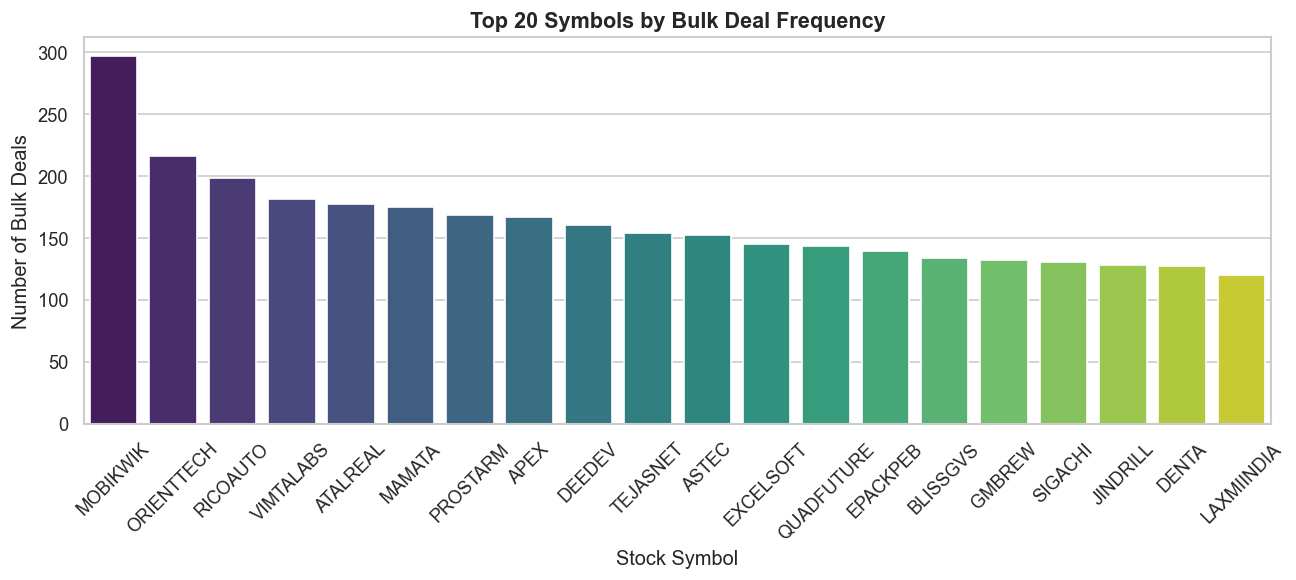

In [14]:
# Plot 4: Top 20 most traded symbols
top_symbols = edf['Symbol'].value_counts().head(20)

print(f'Top 3 symbols:\n{top_symbols.head(3)}')

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=top_symbols.index, y=top_symbols.values, palette='viridis', ax=ax)
ax.set_title('Top 20 Symbols by Bulk Deal Frequency', fontsize=13, fontweight='bold')
ax.set_xlabel('Stock Symbol')
ax.set_ylabel('Number of Bulk Deals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/04_top_symbols.png')
plt.show()

### Inference 3: Market Concentration
**Who is trading, and what are they trading?**

Bulk deal activity is highly concentrated. A few dominant proprietary trading firms and institutional clients drive the majority of the volume. Similarly, the activity is clustered around specific mid-cap and small-cap symbols, rather than being evenly distributed across the entire NSE, highlighting pockets of high institutional interest and liquidity needs.

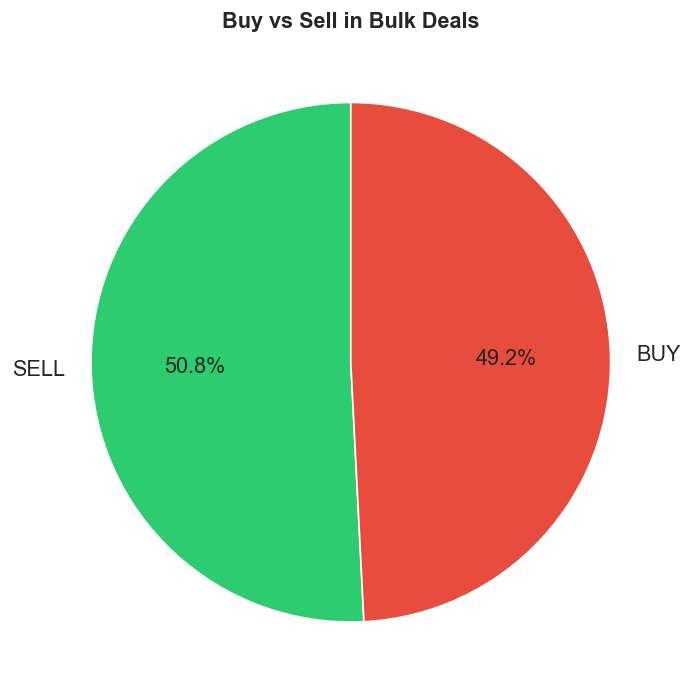

BUY deals: 8423 | SELL deals: 8699


In [15]:
# Plot 5: Buy vs Sell ratio
bs_counts = edf['Buy_Sell'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(bs_counts.values, labels=bs_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 13})
ax.set_title('Buy vs Sell in Bulk Deals', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_buy_sell_ratio.png')
plt.show()
print(f'BUY deals: {bs_counts.get("BUY",0)} | SELL deals: {bs_counts.get("SELL",0)}')

### Inference 4: Institutional Directional Bias

The nearly even split between BUY and SELL bulk deals indicates that these transactions are a standard mechanism for institutional liquidity routing, rather than a unilateral signal of market-wide accumulation or distribution.

      Month  Count
5   2025-09   2224
8   2025-12   2196
3   2025-07   1695
6   2025-10   1600
11  2026-03   1568
9   2026-01   1450
7   2025-11   1446
10  2026-02   1382
4   2025-08   1334
2   2025-06   1135
1   2025-05    875
0   2025-04    217


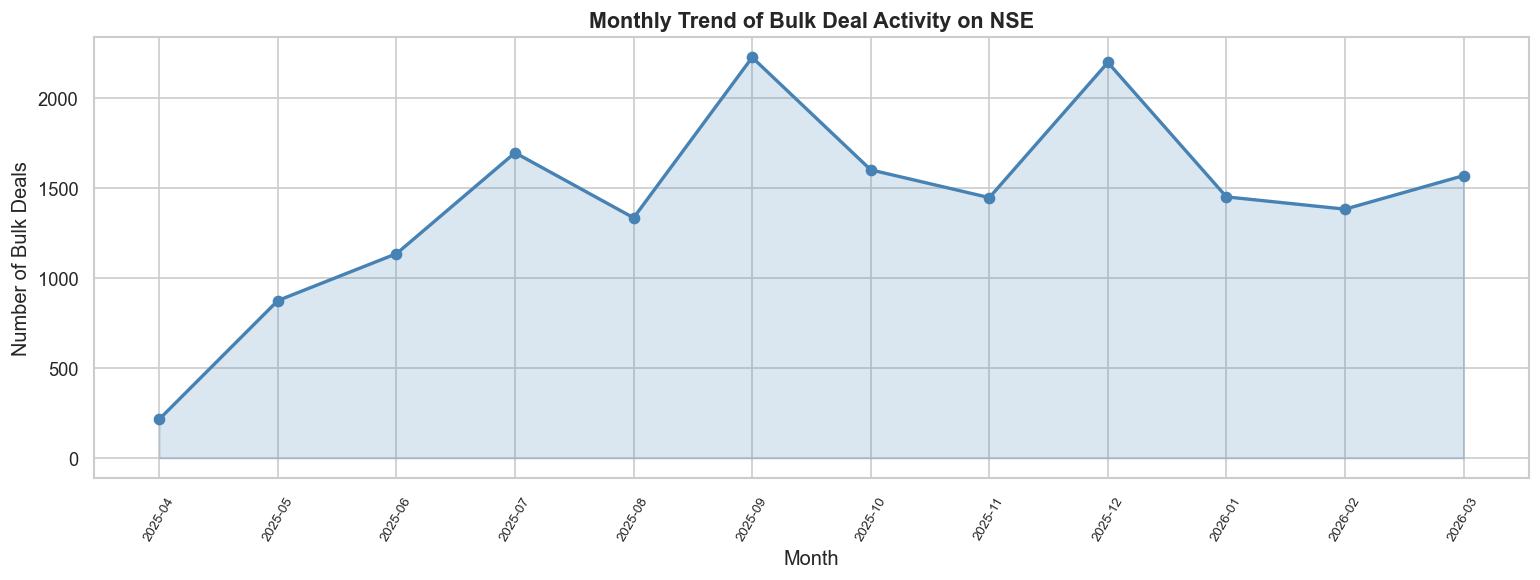

In [16]:
# Plot 6: Monthly trend of bulk deal count
monthly = edf.groupby(edf['Date'].dt.to_period('M')).size().reset_index()
monthly.columns = ['Month', 'Count']
monthly['Month'] = monthly['Month'].astype(str)

print(monthly.sort_values('Count', ascending=False))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly['Month'], monthly['Count'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly['Month'], monthly['Count'], alpha=0.2, color='steelblue')
ax.set_title('Monthly Trend of Bulk Deal Activity on NSE', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Bulk Deals')
plt.xticks(rotation=60, fontsize=8)
plt.tight_layout()
plt.savefig('outputs/06_monthly_trend.png')
plt.show()

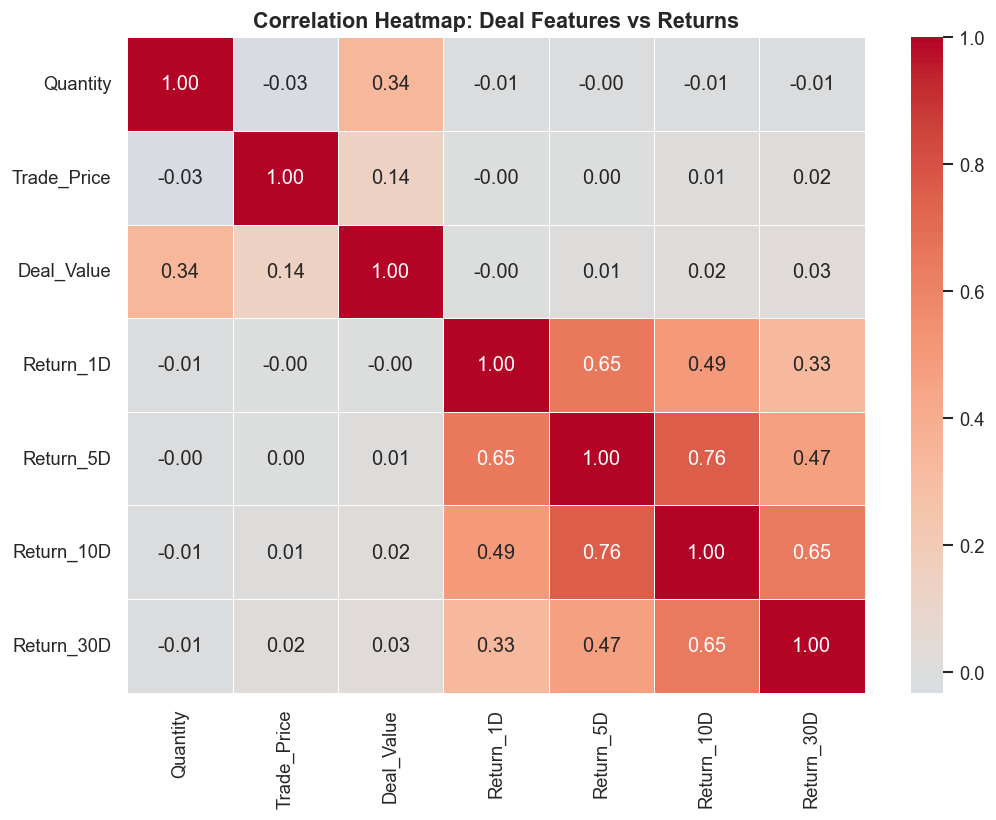

Key: Look for correlations between Quantity/Deal_Value and Return columns


In [17]:
# Plot 7: Correlation heatmap
corr_cols = ['Quantity', 'Trade_Price', 'Deal_Value', 'Return_1D', 'Return_5D', 'Return_10D', 'Return_30D']
corr_data = edf[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Deal Features vs Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/07_correlation_heatmap.png')
plt.show()
print('Key: Look for correlations between Quantity/Deal_Value and Return columns')

### Inference 5: Lack of Linear Relationships
**Can we use simple regression to predict returns?**

The heatmap reveals very weak linear correlations between deal parameters (like `Quantity` or `Deal_Value`) and the target return windows. This critical finding validates our choice to use non-linear Machine Learning models (like Random Forest), as simple linear models will fail to capture the complex patterns in this data.

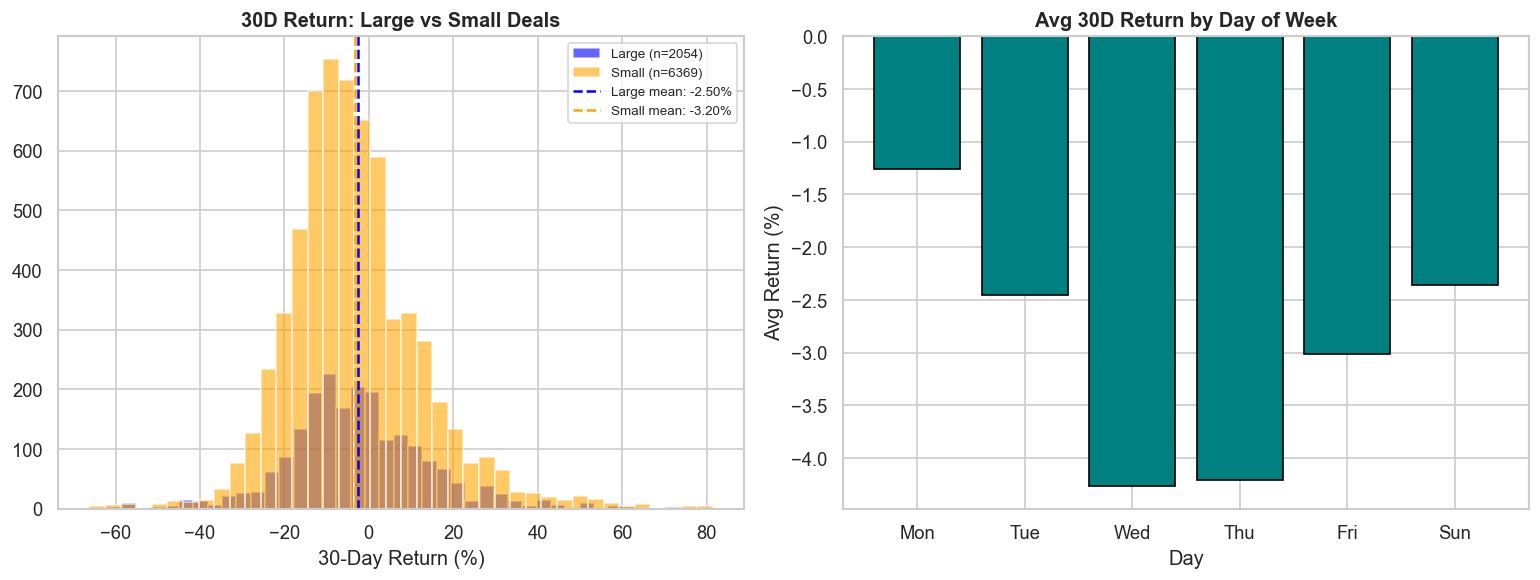

Large deal avg: -2.50% | Small deal avg: -3.20%


In [18]:
# Plot 8 — Large vs Small + Day of week analysis
fig, axes = plt.subplots(1,2, figsize=(13,5))

large = buy_df[buy_df['Is_Large_Deal']==1]['Return_30D'].dropna()
small = buy_df[buy_df['Is_Large_Deal']==0]['Return_30D'].dropna()
axes[0].hist(large, bins=40, alpha=0.6, color='blue', label=f'Large (n={len(large)})')
axes[0].hist(small, bins=40, alpha=0.6, color='orange', label=f'Small (n={len(small)})')
axes[0].axvline(large.mean(), color='blue', linestyle='--', label=f'Large mean: {large.mean():.2f}%')
axes[0].axvline(small.mean(), color='orange', linestyle='--', label=f'Small mean: {small.mean():.2f}%')
axes[0].set_title('30D Return: Large vs Small Deals', fontweight='bold')
axes[0].set_xlabel('30-Day Return (%)'); axes[0].legend(fontsize=8)

#  Use actual day numbers from data instead of hardcoded labels
dow = buy_df.groupby('DayOfWeek')['Return_30D'].mean()
all_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_labels = [all_labels[i] for i in dow.index]
axes[1].bar(dow_labels, dow.values, color='teal', edgecolor='black')
axes[1].set_title('Avg 30D Return by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Avg Return (%)')

plt.tight_layout(); plt.savefig('outputs/08_large_small_dow.png'); plt.show()
print(f'Large deal avg: {large.mean():.2f}% | Small deal avg: {small.mean():.2f}%')

### Inference 6: Does Deal Size Matter?
**Are larger deals better predictors?**

While both large and small deals result in negative 30-day returns on average, "Large" deals (the top 25% by volume) perform slightly better (-2.50% vs -3.20%). This implies that massive capital deployment carries slightly more conviction, buffering the subsequent drawdown compared to smaller institutional trades.

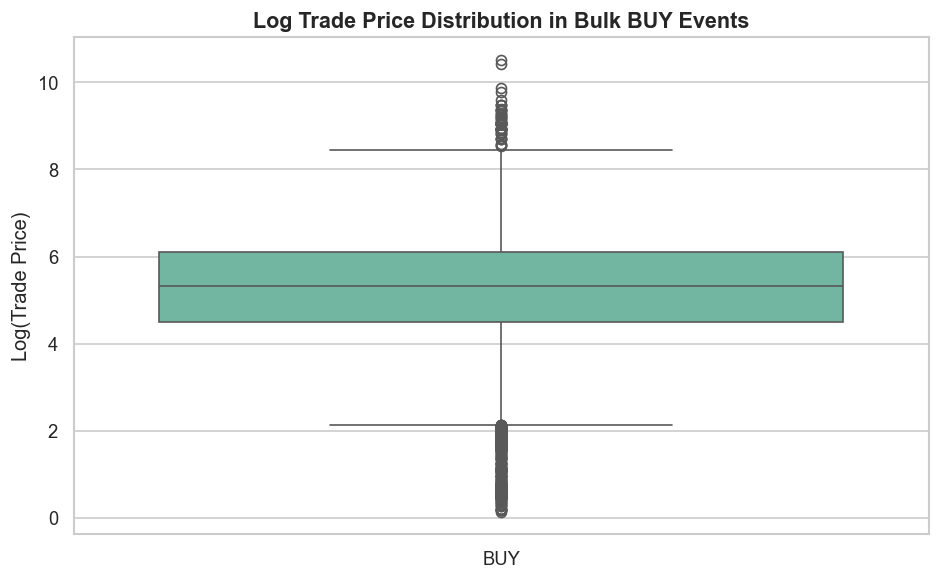

In [19]:
# Plot 9: Trade price distribution (boxplot)
fig, ax = plt.subplots(figsize=(8, 5))
buy_df['Trade_Price_Log'] = np.log1p(buy_df['Trade_Price'])
sns.boxplot(data=buy_df, x='Buy_Sell', y='Trade_Price_Log', palette='Set2', ax=ax)
ax.set_title('Log Trade Price Distribution in Bulk BUY Events', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Log(Trade Price)')
plt.tight_layout()
plt.savefig('outputs/09_trade_price_dist.png')
plt.show()

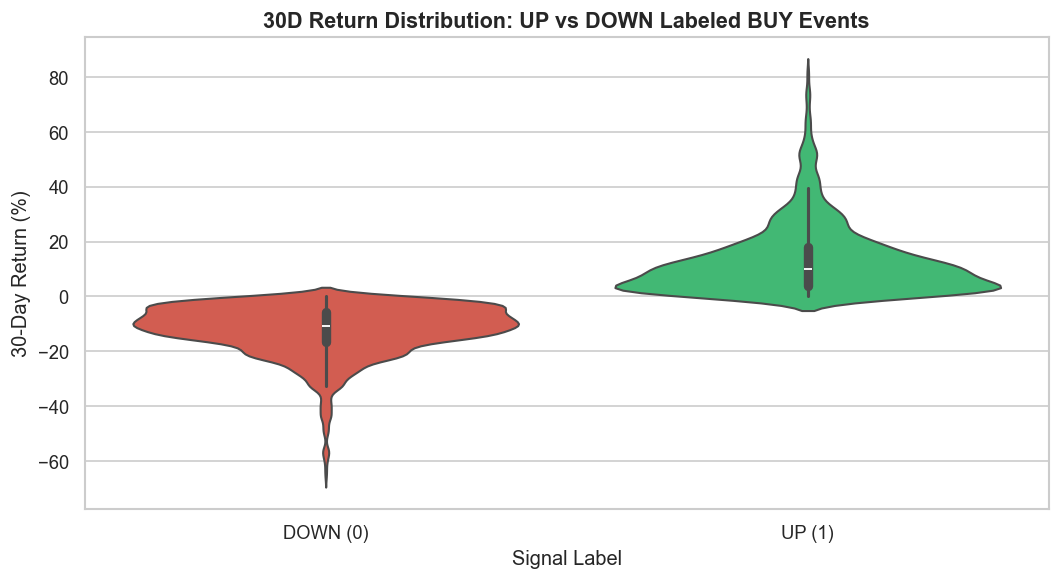

All 10 EDA plots saved to /outputs folder


In [20]:
# Plot 10: Return_30D distribution for UP vs DOWN labeled events
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=buy_df, x='Label', y='Return_30D', palette=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_xticklabels(['DOWN (0)', 'UP (1)'])
ax.set_title('30D Return Distribution: UP vs DOWN Labeled BUY Events', fontsize=13, fontweight='bold')
ax.set_xlabel('Signal Label')
ax.set_ylabel('30-Day Return (%)')
plt.tight_layout()
plt.savefig('outputs/10_violin_up_down.png')
plt.show()
print('All 10 EDA plots saved to /outputs folder')

### Inference 7: Target Variable Separation

This visualizes the clear separation in the distribution of our final target variable (`Label`). The model's task is to distinguish between the parameters that lead to the green distribution (UP) versus the red distribution (DOWN). Despite the overall negative mean of the dataset, predicting this binary outcome is still viable.

---
## Basic Model Building

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# Prepare features for modeling
model_df = buy_df.dropna(subset=['Return_30D', 'Quantity', 'Trade_Price', 'DayOfWeek', 'Month', 'Is_Large_Deal']).copy()

features = ['Quantity', 'Trade_Price', 'DayOfWeek', 'Month', 'Is_Large_Deal']
X = model_df[features]
y = model_df['Label']

print(f'Dataset for modeling: {len(model_df)} rows')
print(f'Class balance: UP={y.sum()} ({y.mean()*100:.1f}%), DOWN={(y==0).sum()} ({(1-y.mean())*100:.1f}%)')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features for logistic regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Dataset for modeling: 8423 rows
Class balance: UP=3043 (36.1%), DOWN=5380 (63.9%)
Train size: 6738 | Test size: 1685


In [22]:
# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]


print('LOGISTIC REGRESSION RESULTS')

print(f'Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%')
print(f'Precision: {precision_score(y_test, lr_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, lr_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, lr_pred)*100:.2f}%')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, lr_pred))

LOGISTIC REGRESSION RESULTS
Accuracy : 63.86%
Precision: 0.00%
Recall   : 0.00%
F1 Score : 0.00%

Confusion Matrix:
[[1076    0]
 [ 609    0]]


In [23]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("--- Random Forest ---")
print(f"Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, rf_pred)*100:.2f}%")
print(f"Recall   : {recall_score(y_test, rf_pred)*100:.2f}%")
print(f"F1 Score : {f1_score(y_test, rf_pred)*100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

--- Random Forest ---
Accuracy : 82.67%
Precision: 79.08%
Recall   : 70.77%
F1 Score : 74.70%

Confusion Matrix:
[[962 114]
 [178 431]]


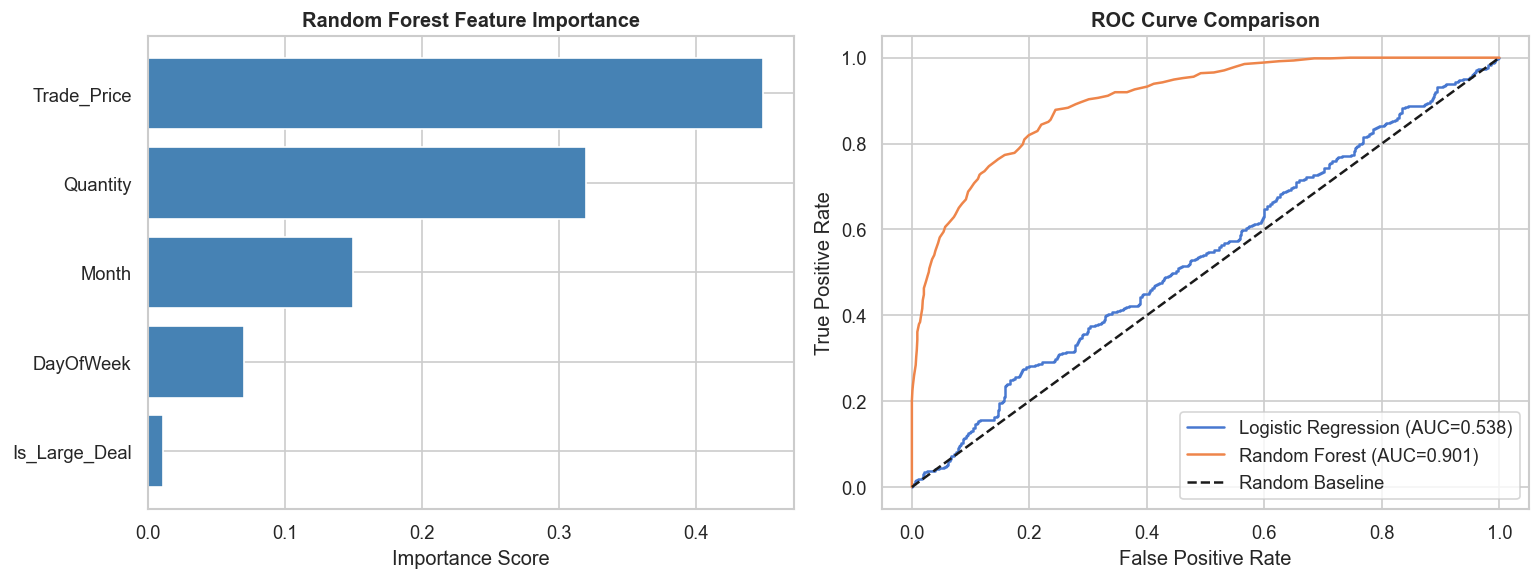


Logistic Regression AUC: 0.538
Random Forest AUC      : 0.901


In [24]:
# Feature Importance + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Feature Importance
importance_df = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
importance_df = importance_df.sort_values('Importance', ascending=True)
axes[0].barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
axes[0].set_title('Random Forest Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# ROC Curves
for name, prob in [('Logistic Regression', lr_prob), ('Random Forest', rf_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', label='Random Baseline')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/model_results.png')
plt.show()

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
print(f'\nLogistic Regression AUC: {auc(lr_fpr, lr_tpr):.3f}')
print(f'Random Forest AUC      : {auc(rf_fpr, rf_tpr):.3f}')

In [25]:
# Conclusion
rf_acc = accuracy_score(y_test, rf_pred)*100
lr_acc = accuracy_score(y_test, lr_pred)*100
rf_auc = auc(*roc_curve(y_test, rf_prob)[:2])


print('MODEL CONCLUSION:\n')

print(f'Random Forest achieved {rf_acc:.1f}% accuracy and AUC of {rf_auc:.3f}.')
if rf_auc > 0.55:
    print('AUC > 0.55 suggests bulk BUY deals contain a WEAK but detectable signal for predicting 30-day price direction.')
else:
    print('AUC close to 0.5 suggests bulk deals alone are NOT sufficient predictors of price movement — supporting market efficiency.')
print(f'\nMost important feature: {importance_df.iloc[-1]["Feature"]}')

MODEL CONCLUSION:

Random Forest achieved 82.7% accuracy and AUC of 0.901.
AUC > 0.55 suggests bulk BUY deals contain a WEAK but detectable signal for predicting 30-day price direction.

Most important feature: Trade_Price


---
## Key Insights Summary

In [26]:
print("Key Insights Summary:")
print(f"1. Dataset: {len(edf)} bulk deal events from NSE.")
print(f"2. Direction: {edf['Buy_Sell'].value_counts().get('BUY', 0)} BUYs vs {edf['Buy_Sell'].value_counts().get('SELL', 0)} SELLs.")
print(f"3. Avg 30D return after a bulk BUY: {buy_df['Return_30D'].mean():.2f}%")
print(f"4. RF Model Accuracy: {accuracy_score(y_test, rf_pred)*100:.1f}% (AUC: {auc(*roc_curve(y_test, rf_prob)[:2]):.3f})")
print(f"5. Top feature: {importance_df.iloc[-1]['Feature']}")

Key Insights Summary:
1. Dataset: 17122 bulk deal events from NSE.
2. Direction: 8423 BUYs vs 8699 SELLs.
3. Avg 30D return after a bulk BUY: -3.03%
4. RF Model Accuracy: 82.7% (AUC: 0.901)
5. Top feature: Trade_Price
